In [1]:
"""
ResNet-50 + CBAM for Thoracic Disease Classification
Enhanced with Convolutional Block Attention Module (CBAM)

CBAM adds channel and spatial attention after each residual block,
helping the model focus on relevant anatomical features in X-rays.
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CBAM ATTENTION MODULE IMPLEMENTATION
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        # Max pooling
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        # Combine and apply sigmoid
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling along channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # Max pooling along channel axis
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # Concatenate
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        
        # Apply convolution
        spatial_attention = self.conv(concat)
        
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module (CBAM)"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super(CBAM, self).get_config()
        return config

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 0.0005

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Architecture: ResNet-50 + CBAM")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.0005
  Architecture: ResNet-50 + CBAM


In [4]:
# ============================================================================
# DATASET LOADING
# ============================================================================

BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"\nLoading balanced Pneumothorax dataset...")

try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    exit(1)

print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")



Loading balanced Pneumothorax dataset...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

First 3 rows:
        Image_Index                      Finding_Labels  Pneumothorax  \
0  00001974_002.png           Infiltration|Pneumothorax             1   
1  00012620_013.png  Atelectasis|Consolidation|Effusion             0   
2  00014870_000.png                  Consolidation|Mass             0   

                      Path  Binary_Label  
0  images\00001974_002.png             1  
1  images\00012620_013.png             0  
2  images\00014870_000.png             0  

=== Final Dataset Summary ===
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302 (50.0%)


In [5]:
# ============================================================================
# DATASET SPLITTING
# ============================================================================

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['binary_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")

print(f"\nTest set: {len(test_df):,} samples")
print(f"  Positive: {test_df['binary_label'].sum():,} ({test_df['binary_label'].sum()/len(test_df)*100:.1f}%)")

os.makedirs('./output', exist_ok=True)
test_df.to_csv('./output/pneumothorax_cbam_test_set.csv', index=False)
print("\n✓ Test set saved for final evaluation")


=== Dataset Splits (Stratified) ===
Training set: 8,483 samples
  Positive: 4,242 (50.0%)

Validation set: 1,060 samples
  Positive: 530 (50.0%)

Test set: 1,061 samples
  Positive: 530 (50.0%)

✓ Test set saved for final evaluation


In [6]:
# ============================================================================
# TF.DATA PIPELINE
# ============================================================================

def create_tf_dataset(df, batch_size, shuffle=True, augment=True):
    """Enhanced tf.data pipeline with better augmentation"""
    
    def load_and_preprocess(image_path, label):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
            img = tf.image.random_brightness(img, max_delta=0.1)
            img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
            
            if tf.random.uniform([]) > 0.5:
                crop_size = tf.random.uniform([], 0.85, 1.0)
                h, w = IMAGE_SIZE, IMAGE_SIZE
                crop_h = tf.cast(h * crop_size, tf.int32)
                crop_w = tf.cast(w * crop_size, tf.int32)
                img = tf.image.random_crop(img, [crop_h, crop_w, 3])
                img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, label
    
    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=2000, seed=42)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("Creating tf.data pipelines...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)
test_dataset = create_tf_dataset(test_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✅ tf.data pipelines created:")
print(f"  Training batches: {len(train_dataset)}")
print(f"  Validation batches: {len(val_dataset)}")
print(f"  Test batches: {len(test_dataset)}")

Creating tf.data pipelines...
✅ tf.data pipelines created:
  Training batches: 266
  Validation batches: 34
  Test batches: 34


In [7]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 + CBAM (Simplified Approach)
# ============================================================================

def create_resnet50_cbam(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    dropout_rate=0.3,
    cbam_ratio=8,
    cbam_kernel_size=7
):
    """
    Create ResNet-50 with CBAM attention modules
    
    Simplified approach: Add CBAM after the base ResNet-50 backbone
    This is cleaner and avoids skip connection issues
    
    Args:
        input_shape: Input image shape
        dropout_rate: Dropout rate for regularization
        cbam_ratio: Channel reduction ratio for CBAM
        cbam_kernel_size: Kernel size for spatial attention
    """
    
    print("\nBuilding ResNet-50 + CBAM...")
    
    # Load base ResNet-50
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling=None  # No pooling - we'll add CBAM then pool
    )
    
    print(f"  ✓ ResNet-50V2 base loaded")
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Build full model with CBAM
    inputs = layers.Input(shape=input_shape)
    
    # Pass through ResNet backbone
    x = base_model(inputs, training=False)
    print(f"  ✓ ResNet output shape: {base_model.output.shape}")
    
    # Add CBAM attention module
    x = CBAM(ratio=cbam_ratio, kernel_size=cbam_kernel_size, 
            name='cbam_attention')(x)
    print(f"  ✓ CBAM module added (ratio={cbam_ratio}, kernel={cbam_kernel_size})")
    
    # Global pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Regularization
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    
    # Output layer
    outputs = layers.Dense(
        1, 
        activation='sigmoid',
        kernel_regularizer=tf.keras.regularizers.l2(0.01),
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='PneumothoraxModel_CBAM')
    
    return model, base_model

print("\nCreating ResNet-50 + CBAM model...")
model, enhanced_base = create_resnet50_cbam(
    dropout_rate=0.3,
    cbam_ratio=8,  # Standard CBAM configuration
    cbam_kernel_size=7
)

print(f"\n=== Model Architecture Summary ===")
print(f"  Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Non-trainable parameters: {model.count_params() - trainable_params:,}")
print(f"  Base model frozen: {not enhanced_base.trainable}")

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['binary_label']),
    y=train_df['binary_label']
)
class_weights = dict(enumerate(class_weights_array))

print(f"\nClass weights:")
print(f"  Negative (0): {class_weights[0]:.3f}")
print(f"  Positive (1): {class_weights[1]:.3f}")


Creating ResNet-50 + CBAM model...

Building ResNet-50 + CBAM...
  ✓ ResNet-50V2 base loaded
  ✓ ResNet output shape: (None, 7, 7, 2048)
  ✓ CBAM module added (ratio=8, kernel=7)

=== Model Architecture Summary ===
  Total parameters: 24,617,827
  Trainable parameters: 1,053,027
  Non-trainable parameters: 23,564,800
  Base model frozen: True

Class weights:
  Negative (0): 1.000
  Positive (1): 1.000


In [8]:
# ============================================================================
# MODEL COMPILATION
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')
    ]
)

print("\n=== Model Compiled ===")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: binary_crossentropy")
print(f"  Metrics: AUC, Precision, Recall, Accuracy")


=== Model Compiled ===
  Optimizer: Adam (lr=0.0005)
  Loss: binary_crossentropy
  Metrics: AUC, Precision, Recall, Accuracy


In [9]:
# ============================================================================
# CALLBACKS
# ============================================================================

callbacks = [
    ModelCheckpoint(
        filepath='./output/resnet50_cbam_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
        min_delta=0.0001
    )
]


In [10]:
# ============================================================================
# TWO-STAGE TRAINING
# ============================================================================

print("\n" + "="*80)
print("TWO-STAGE TRAINING WITH CBAM")
print("="*80)
print("Stage 1: Train with frozen base (CBAM modules trainable)")
print("Stage 2: Fine-tune entire network with CBAM")
print("="*80 + "\n")

# STAGE 1: Train with frozen base
print("\n" + "="*80)
print("STAGE 1: Training with Frozen Base Model (CBAM Active)")
print("="*80)

history_stage1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


TWO-STAGE TRAINING WITH CBAM
Stage 1: Train with frozen base (CBAM modules trainable)
Stage 2: Fine-tune entire network with CBAM


STAGE 1: Training with Frozen Base Model (CBAM Active)
Epoch 1/10
266/266 [==============================] - ETA: 0s - loss: 0.6707 - binary_accuracy: 0.5998 - auc: 0.6431 - precision: 0.6073 - recall: 0.5651 - accuracy: 0.5998
Epoch 1: val_auc improved from -inf to 0.76915, saving model to ./output\resnet50_cbam_best.keras
266/266 [==============================] - 34s 96ms/step - loss: 0.6707 - binary_accuracy: 0.5998 - auc: 0.6431 - precision: 0.6073 - recall: 0.5651 - accuracy: 0.5998 - val_loss: 0.6010 - val_binary_accuracy: 0.7009 - val_auc: 0.7692 - val_precision: 0.7261 - val_recall: 0.6453 - val_accuracy: 0.7009 - lr: 5.0000e-04
Epoch 2/10
265/266 [============================>.] - ETA: 0s - loss: 0.6283 - binary_accuracy: 0.6603 - auc: 0.7156 - precision: 0.6578 - recall: 0.6685 - accuracy: 0.6603
Epoch 2: val_auc improved from 0.76915 to 0.7776

In [11]:
# STAGE 2: Unfreeze and fine-tune
print("\n" + "="*80)
print("STAGE 2: Fine-tuning Entire Network + CBAM")
print("="*80)

enhanced_base.trainable = True

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE * 0.1),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')
    ]
)

print(f"\nFine-tuning with learning rate: {LEARNING_RATE * 0.1}")
print(f"Trainable parameters: {sum([tf.size(v).numpy() for v in model.trainable_variables]):,}")

history_stage2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    initial_epoch=10,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Combine histories
history = history_stage1
for key in history_stage2.history.keys():
    history.history[key].extend(history_stage2.history[key])

# Save final model
model.save('./output/resnet50_cbam_final.keras')

print("\n" + "="*80)
print("✓ TRAINING COMPLETE!")
print("="*80)
print("Models saved:")
print("  - Best model: ./output/resnet50_cbam_best.keras")
print("  - Final model: ./output/resnet50_cbam_final.keras")
print("\nCBAM Attention modules have been successfully integrated!")
print("The model now has enhanced focus on relevant anatomical features.")
print("="*80)


STAGE 2: Fine-tuning Entire Network + CBAM

Fine-tuning with learning rate: 5e-05
Trainable parameters: 24,572,387
Epoch 11/50
266/266 [==============================] - ETA: 0s - loss: 0.6456 - binary_accuracy: 0.6425 - auc: 0.6937 - precision: 0.6447 - recall: 0.6351 - accuracy: 0.6425
Epoch 11: val_auc improved from 0.79340 to 0.81645, saving model to ./output\resnet50_cbam_best.keras
266/266 [==============================] - 63s 221ms/step - loss: 0.6456 - binary_accuracy: 0.6425 - auc: 0.6937 - precision: 0.6447 - recall: 0.6351 - accuracy: 0.6425 - val_loss: 0.5883 - val_binary_accuracy: 0.6849 - val_auc: 0.8165 - val_precision: 0.8475 - val_recall: 0.4509 - val_accuracy: 0.6849 - lr: 5.0000e-05
Epoch 12/50
265/266 [============================>.] - ETA: 0s - loss: 0.5890 - binary_accuracy: 0.7005 - auc: 0.7648 - precision: 0.7071 - recall: 0.6847 - accuracy: 0.7005
Epoch 12: val_auc improved from 0.81645 to 0.85037, saving model to ./output\resnet50_cbam_best.keras
266/266 [==

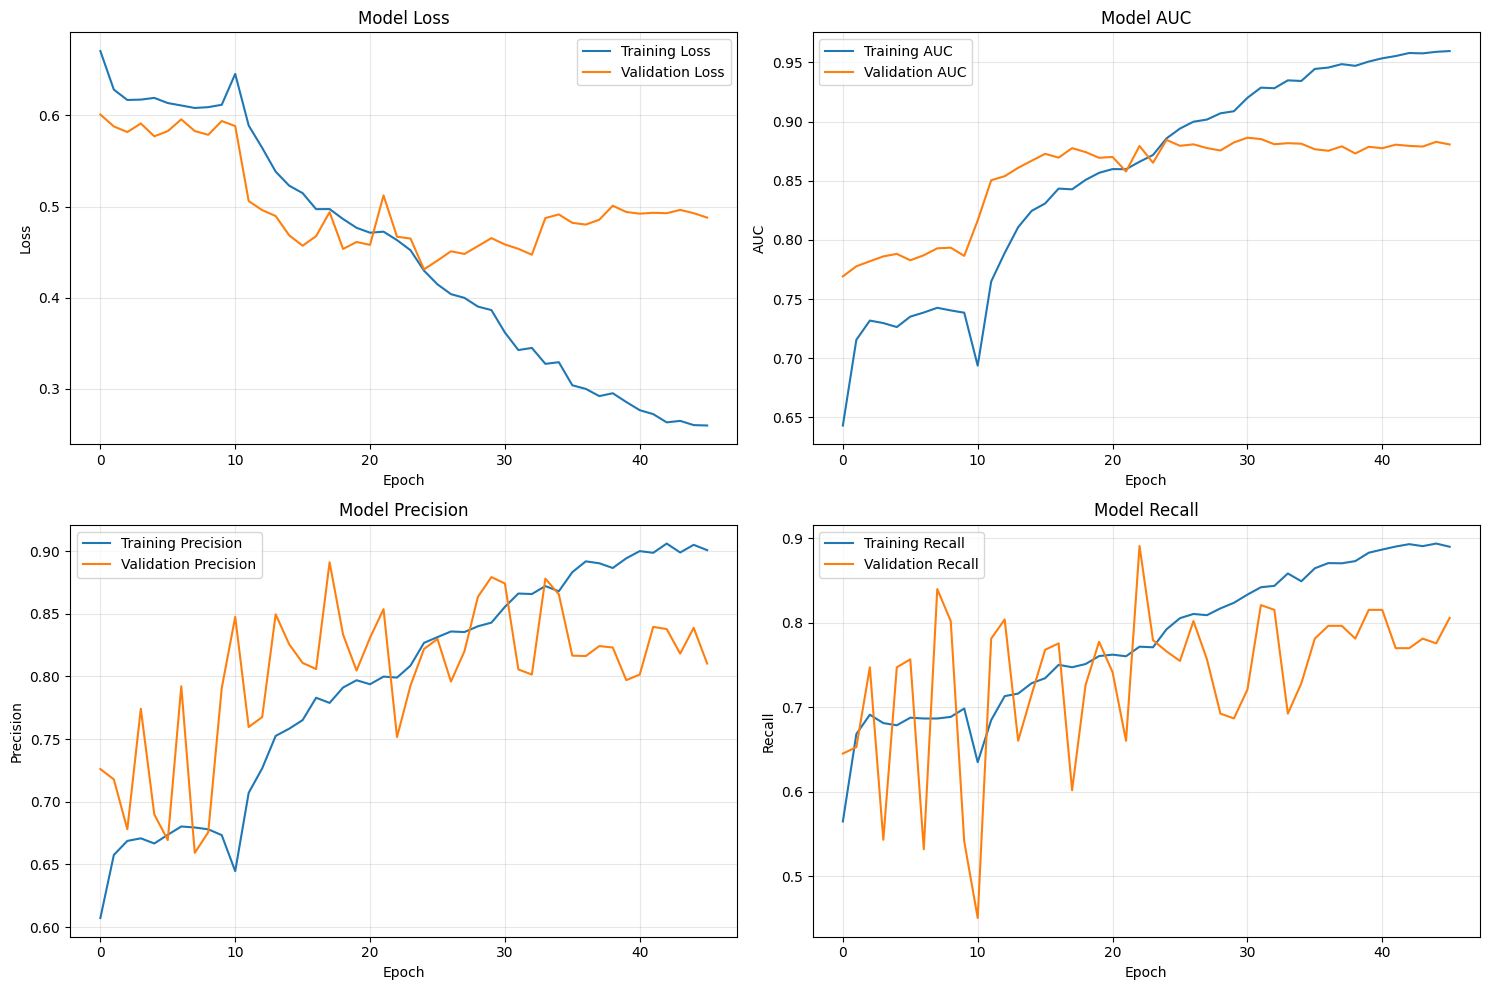

In [12]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

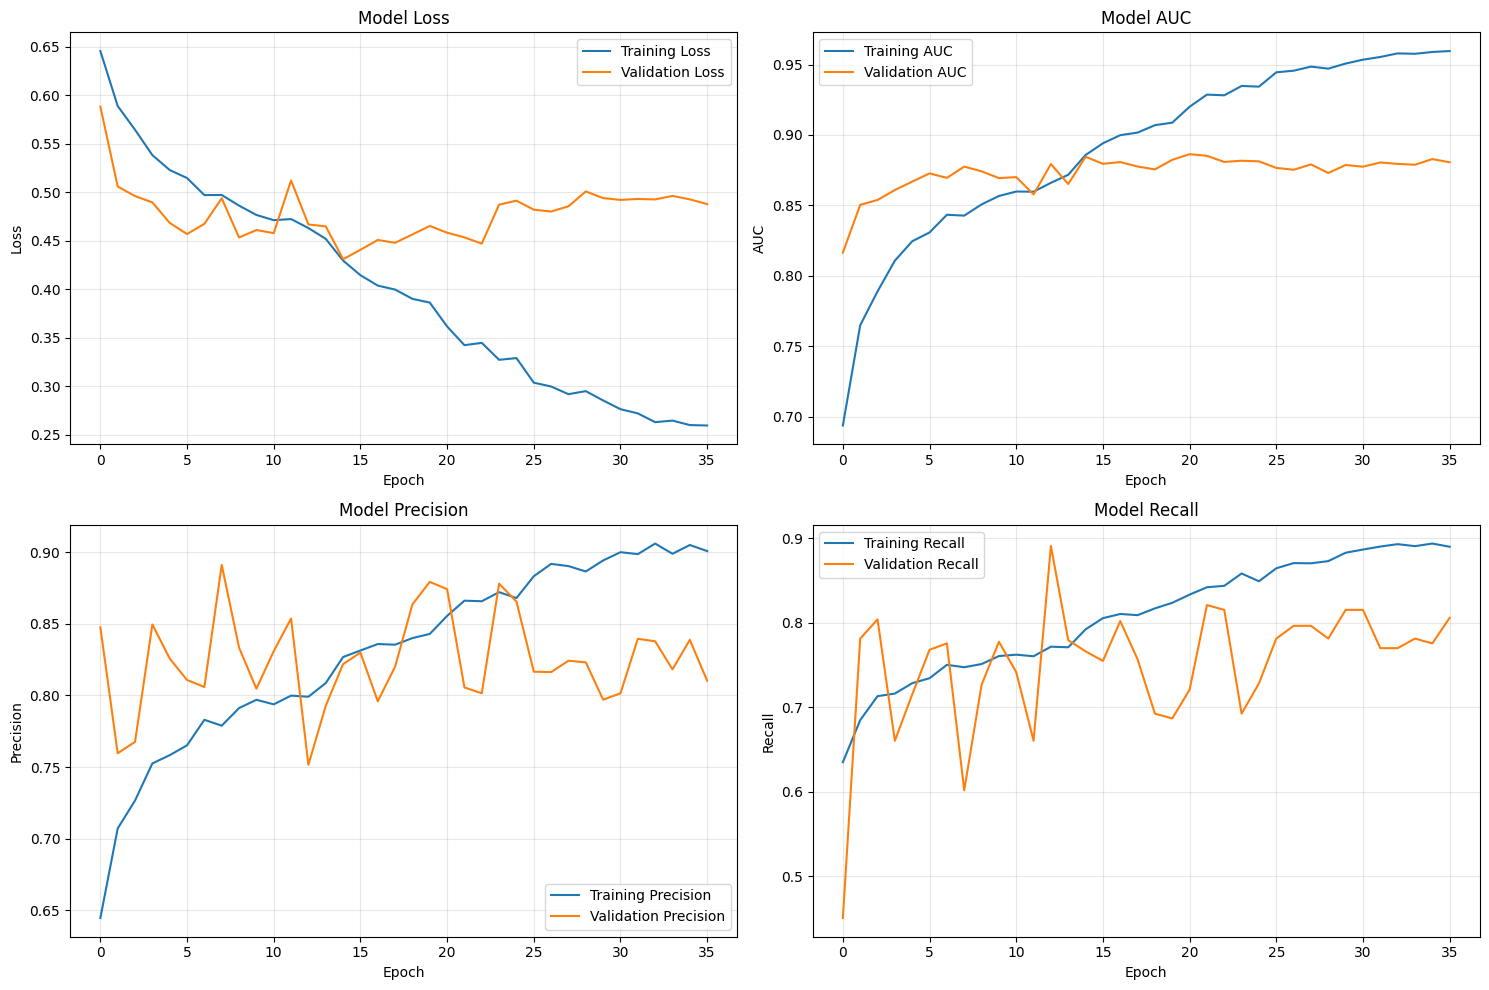

In [13]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_stage2)

In [16]:
# ============================================================================
# COMPREHENSIVE EVALUATION - BINARY CLASSIFICATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
val_predictions = model.predict(val_dataset, verbose=1)

# Get true labels from validation dataframe - FIXED
y_true = val_df['binary_label'].values  # Use binary_label column
y_pred_probs = val_predictions.flatten()  # Flatten to 1D array
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

print(f"\nPredictions shape: {y_pred_probs.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Unique predictions: {np.unique(y_pred)}")
print(f"Unique true labels: {np.unique(y_true)}")

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs)
print(f"\n📊 VALIDATION METRICS:")
print(f"  AUC Score: {auc_score:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Pneumothorax', 'Pneumothorax']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\n🔢 Confusion Matrix:")
print(f"  True Negatives: {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives: {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\n📈 Detailed Metrics:")
print(f"  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  F1-Score: {f1_score:.4f}")
print(f"  Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
34/34 [==============================] - 3s 77ms/step

Predictions shape: (1060,)
True labels shape: (1060,)
Unique predictions: [0 1]
Unique true labels: [0 1]

📊 VALIDATION METRICS:
  AUC Score: 0.8863

📋 Classification Report:
                 precision    recall  f1-score   support

No Pneumothorax       0.76      0.90      0.82       530
   Pneumothorax       0.87      0.72      0.79       530

       accuracy                           0.81      1060
      macro avg       0.82      0.81      0.81      1060
   weighted avg       0.82      0.81      0.81      1060


🔢 Confusion Matrix:
  True Negatives: 475
  False Positives: 55
  False Negatives: 148
  True Positives: 382

📈 Detailed Metrics:
  Sensitivity (Recall): 0.7208
  Specificity: 0.8962
  Precision: 0.8741
  F1-Score: 0.7901
  Accuracy: 0.8085


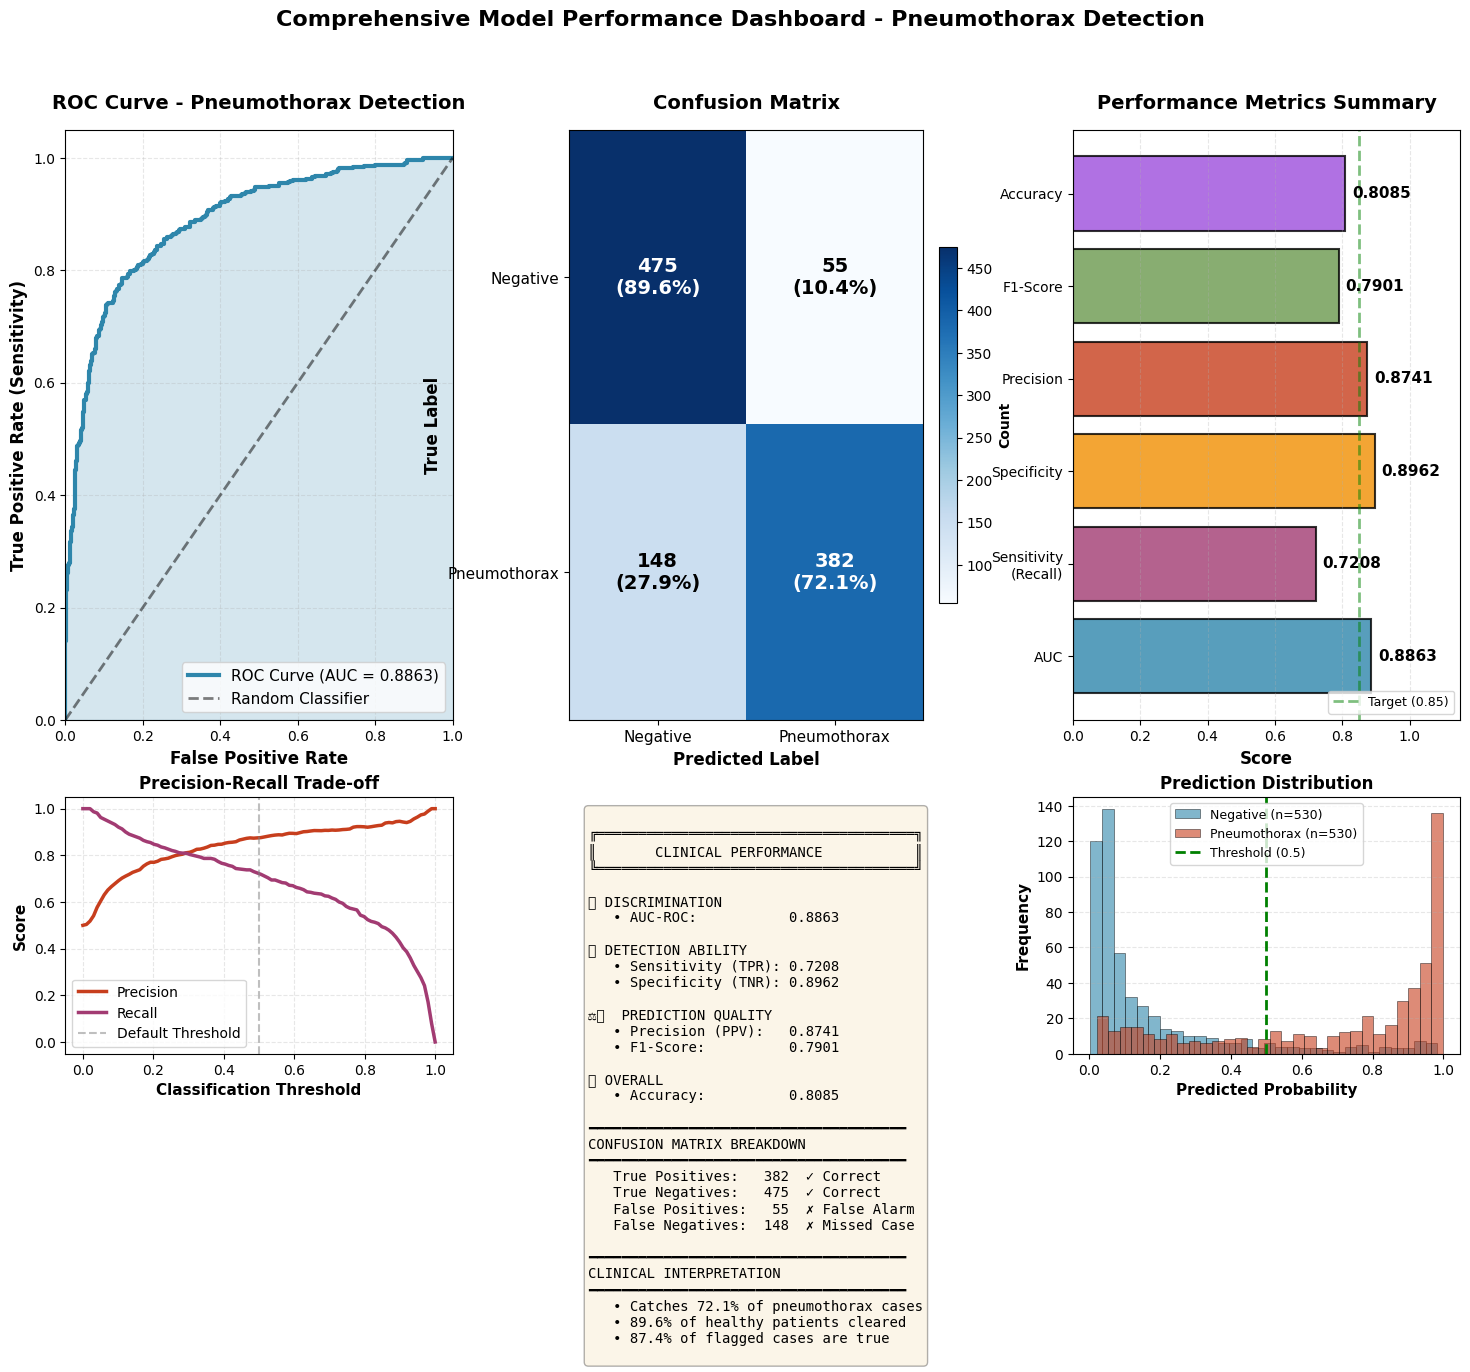


✅ Comprehensive metrics dashboard saved to:
   ./output/comprehensive_metrics_dashboard.png


In [17]:
# ============================================================================
# VISUAL METRICS DASHBOARD - AUC, PRECISION, RECALL, F1-SCORE
# ============================================================================

from sklearn.metrics import roc_curve, auc as sklearn_auc
import matplotlib.patches as mpatches

# Calculate all metrics
auc_score = roc_auc_score(y_true, y_pred_probs)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# ============================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# 1. ROC CURVE (Top Left - Large)
# ============================================================================
ax1 = fig.add_subplot(gs[0:2, 0])
ax1.plot(fpr, tpr, color='#2E86AB', linewidth=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random Classifier')
ax1.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax1.set_title('ROC Curve - Pneumothorax Detection', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])

# ============================================================================
# 2. CONFUSION MATRIX (Top Middle - Large)
# ============================================================================
ax2 = fig.add_subplot(gs[0:2, 1])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negative', 'Pneumothorax'], fontsize=11)
ax2.set_yticklabels(['Negative', 'Pneumothorax'], fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Count', fontsize=10, fontweight='bold')

# ============================================================================
# 3. METRIC BARS (Top Right - Large)
# ============================================================================
ax3 = fig.add_subplot(gs[0:2, 2])
metrics = ['AUC', 'Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1-Score', 'Accuracy']
values = [auc_score, sensitivity, specificity, precision, f1_score, accuracy]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#9D4EDD']

bars = ax3.barh(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, values)):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax3.set_xlim([0, 1.15])
ax3.set_xlabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--')
ax3.axvline(x=0.85, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (0.85)')
ax3.legend(loc='lower right', fontsize=9)

# ============================================================================
# 4. PRECISION-RECALL TRADE-OFF (Bottom Left)
# ============================================================================
ax4 = fig.add_subplot(gs[2, 0])
precisions = []
recalls = []
for threshold in np.linspace(0, 1, 100):
    y_pred_temp = (y_pred_probs >= threshold).astype(int)
    if y_pred_temp.sum() > 0:
        tp_temp = np.sum((y_true == 1) & (y_pred_temp == 1))
        fp_temp = np.sum((y_true == 0) & (y_pred_temp == 1))
        fn_temp = np.sum((y_true == 1) & (y_pred_temp == 0))
        prec_temp = tp_temp / (tp_temp + fp_temp) if (tp_temp + fp_temp) > 0 else 0
        rec_temp = tp_temp / (tp_temp + fn_temp) if (tp_temp + fn_temp) > 0 else 0
        precisions.append(prec_temp)
        recalls.append(rec_temp)
    else:
        precisions.append(1.0)
        recalls.append(0.0)

ax4.plot(np.linspace(0, 1, 100), precisions, label='Precision', color='#C73E1D', linewidth=2.5)
ax4.plot(np.linspace(0, 1, 100), recalls, label='Recall', color='#A23B72', linewidth=2.5)
ax4.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Default Threshold')
ax4.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--')

# ============================================================================
# 5. CLINICAL METRICS (Bottom Middle)
# ============================================================================
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

# Create text summary
summary_text = f"""
╔══════════════════════════════════════╗
║       CLINICAL PERFORMANCE           ║
╚══════════════════════════════════════╝

📊 DISCRIMINATION
   • AUC-ROC:           {auc_score:.4f}
   
🎯 DETECTION ABILITY
   • Sensitivity (TPR): {sensitivity:.4f}
   • Specificity (TNR): {specificity:.4f}
   
⚖️  PREDICTION QUALITY
   • Precision (PPV):   {precision:.4f}
   • F1-Score:          {f1_score:.4f}
   
✅ OVERALL
   • Accuracy:          {accuracy:.4f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONFUSION MATRIX BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   True Positives:  {tp:4d}  ✓ Correct
   True Negatives:  {tn:4d}  ✓ Correct
   False Positives: {fp:4d}  ✗ False Alarm
   False Negatives: {fn:4d}  ✗ Missed Case

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLINICAL INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Catches {sensitivity:.1%} of pneumothorax cases
   • {specificity:.1%} of healthy patients cleared
   • {precision:.1%} of flagged cases are true
"""

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# ============================================================================
# 6. PROBABILITY DISTRIBUTION (Bottom Right)
# ============================================================================
ax6 = fig.add_subplot(gs[2, 2])

# Separate predictions by true label
y_pred_probs_negative = y_pred_probs[y_true == 0]
y_pred_probs_positive = y_pred_probs[y_true == 1]

ax6.hist(y_pred_probs_negative, bins=30, alpha=0.6, color='#2E86AB', 
         label=f'Negative (n={len(y_pred_probs_negative)})', edgecolor='black', linewidth=0.5)
ax6.hist(y_pred_probs_positive, bins=30, alpha=0.6, color='#C73E1D', 
         label=f'Pneumothorax (n={len(y_pred_probs_positive)})', edgecolor='black', linewidth=0.5)
ax6.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax6.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Prediction Distribution', fontsize=12, fontweight='bold')
ax6.legend(loc='upper center', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y', linestyle='--')

# ============================================================================
# OVERALL TITLE
# ============================================================================
fig.suptitle('Comprehensive Model Performance Dashboard - Pneumothorax Detection', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('./output/comprehensive_metrics_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*80)
print("✅ Comprehensive metrics dashboard saved to:")
print("   ./output/comprehensive_metrics_dashboard.png")
print("="*80)